1 — Import et chargement des données brutes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Chargement des deux datasets
df_renouv = pd.read_csv("data/renouvelables.csv")
df_elec = pd.read_csv("data/green_bonds.csv")

print("=== DATASET 1 : Énergies Renouvelables ===")
print(f"Lignes : {len(df_renouv)} | Colonnes : {list(df_renouv.columns)}")
print(df_renouv.head())

print("\n=== DATASET 2 : Électricité Renouvelable ===")
print(f"Lignes : {len(df_elec)} | Colonnes : {list(df_elec.columns)}")
print(df_elec.head())

=== DATASET 1 : Énergies Renouvelables ===
Lignes : 150 | Colonnes : ['economy', 'year', 'value', 'country']
  economy  year  value  country
0     AUT  2007   29.0  Austria
1     BEL  2007    3.4  Belgium
2     DEU  2007   10.5  Germany
3     DNK  2007   17.7  Denmark
4     ESP  2007    9.0    Spain

=== DATASET 2 : Électricité Renouvelable ===
Lignes : 120 | Colonnes : ['economy', 'year', 'elec_renouvelable', 'country']
  economy  year  elec_renouvelable  country
0     AUT  2010          67.755820  Austria
1     BEL  2010           8.441797  Belgium
2     DEU  2010          17.623831  Germany
3     DNK  2010          31.983377  Denmark
4     ESP  2010          33.490600    Spain


Ce qu'on voit :

renouvelables.csv : 150 lignes · 10 pays · 2007-2021
green_bonds.csv : 120 lignes · 10 pays · 2010-2021



2 — Statistiques descriptives

In [3]:
print("=== STATISTIQUES DATASET 1 ===")
print(df_renouv.describe().round(2))

print("\n=== STATISTIQUES DATASET 2 ===")
print(df_elec.describe().round(2))

print("\n=== PAYS COUVERTS ===")
print(sorted(df_renouv["country"].unique()))

print("\n=== PÉRIODE COUVERTE ===")
print(f"Renouvelables : {df_renouv['year'].min()} → {df_renouv['year'].max()}")
print(f"Électricité   : {df_elec['year'].min()} → {df_elec['year'].max()}")

=== STATISTIQUES DATASET 1 ===
          year   value
count   150.00  150.00
mean   2014.00   19.52
std       4.33   13.36
min    2007.00    3.40
25%    2010.00   10.62
50%    2014.00   15.20
75%    2018.00   28.50
max    2021.00   57.90

=== STATISTIQUES DATASET 2 ===
          year  elec_renouvelable
count   120.00             120.00
mean   2015.50              36.81
std       3.47              22.19
min    2010.00               7.40
25%    2012.75              17.58
50%    2015.50              32.44
75%    2018.25              55.45
max    2021.00              82.54

=== PAYS COUVERTS ===
['Austria', 'Belgium', 'Denmark', 'France', 'Germany', 'Italy', 'Netherlands', 'Poland', 'Spain', 'Sweden']

=== PÉRIODE COUVERTE ===
Renouvelables : 2007 → 2021
Électricité   : 2010 → 2021


Ce qu'on observe :

Moyenne renouvelables : 19.52% — encore loin des objectifs européens
Moyenne électricité renouvelable : 36.81% — plus élevée car l'électricité se décarbonne plus vite
Max renouvelables : 57.9% — c'est la Suède !
Max électricité : 82.54% — probablement l'Autriche (hydroélectrique)

3 — Visualisation des données brutes

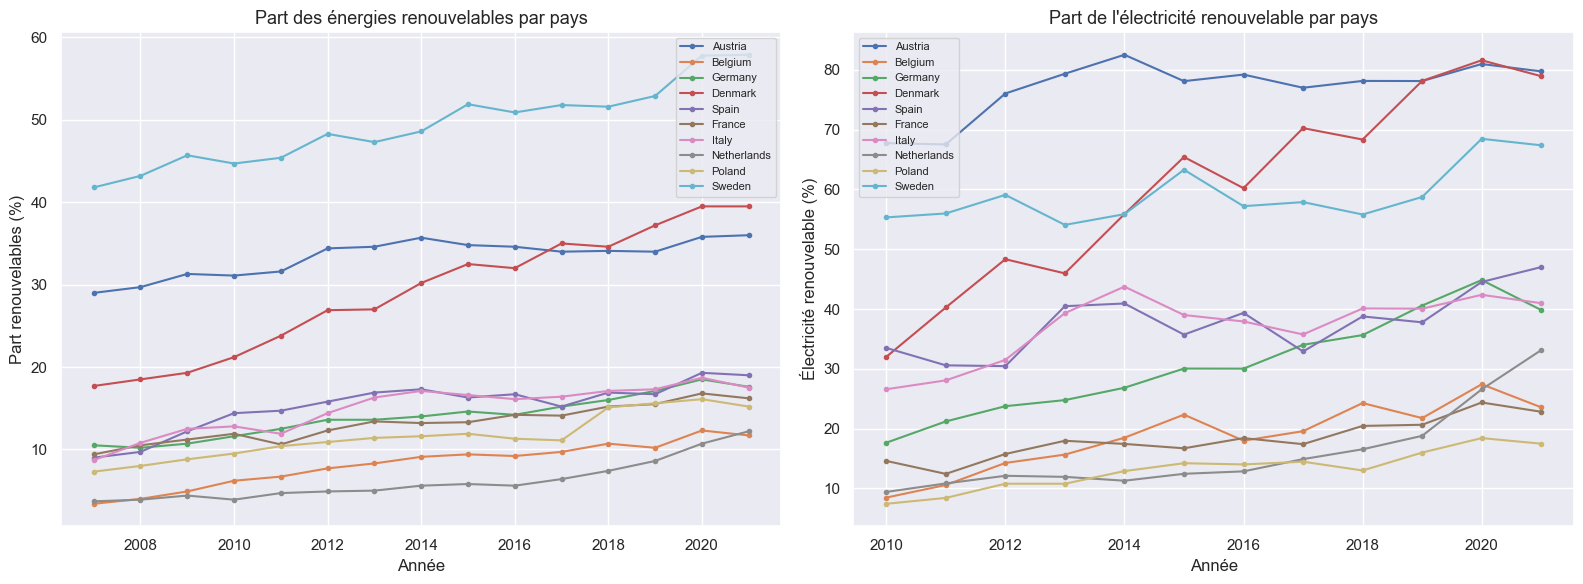

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Renouvelables par pays
for country in df_renouv["country"].unique():
    data = df_renouv[df_renouv["country"] == country]
    axes[0].plot(data["year"], data["value"], marker="o", markersize=3, label=country)
axes[0].set_title("Part des énergies renouvelables par pays", fontsize=13)
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Part renouvelables (%)")
axes[0].legend(fontsize=8)

# Graphique 2 : Électricité renouvelable par pays
for country in df_elec["country"].unique():
    data = df_elec[df_elec["country"] == country]
    axes[1].plot(data["year"], data["elec_renouvelable"], marker="o", markersize=3, label=country)
axes[1].set_title("Part de l'électricité renouvelable par pays", fontsize=13)
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Électricité renouvelable (%)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Ce qu'on observe :

Sweden domine largement les renouvelables (~55%)
Austria domine l'électricité renouvelable (~80% grâce à l'hydroélectrique)
Poland et Belgium sont les moins avancés
Tendance générale à la hausse pour tous les pays

4 — Sauvegarde des données brutes et résumé

In [5]:
# Sauvegarde données brutes
df_renouv.to_csv("data/brutes_renouvelables.csv", index=False)
df_elec.to_csv("data/brutes_electricite.csv", index=False)

print("✅ Données brutes sauvegardées !")
print(f"\nRécapitulatif de l'exploration :")
print(f"  - Dataset 1 : {len(df_renouv)} lignes · {df_renouv['country'].nunique()} pays · {df_renouv['year'].min()}-{df_renouv['year'].max()}")
print(f"  - Dataset 2 : {len(df_elec)} lignes · {df_elec['country'].nunique()} pays · {df_elec['year'].min()}-{df_elec['year'].max()}")
print(f"  - Valeur max renouvelables : {df_renouv['value'].max()}% ({df_renouv.loc[df_renouv['value'].idxmax(), 'country']})")
print(f"  - Valeur max électricité   : {df_elec['elec_renouvelable'].max():.1f}% ({df_elec.loc[df_elec['elec_renouvelable'].idxmax(), 'country']})")

✅ Données brutes sauvegardées !

Récapitulatif de l'exploration :
  - Dataset 1 : 150 lignes · 10 pays · 2007-2021
  - Dataset 2 : 120 lignes · 10 pays · 2010-2021
  - Valeur max renouvelables : 57.9% (Sweden)
  - Valeur max électricité   : 82.5% (Austria)
